In [ ]:
import pandas as pd
import numpy as np

In [2]:
import pandas as pd
import seaborn as sns

In [ ]:
#https://www.kaggle.com/datasets/sonalshinde123/student-placement-dataset
from pandas import read_csv
df=read_csv('C:\\Users\\vippa\\OneDrive\\Desktop\\KLH\\ML\\Placement Prediction\\data\\Prediction.csv')

In [4]:
# Numerical vs Categorical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:", list(numerical_features))
print("Categorical Features:", list(categorical_features))

Numerical Features: ['StudentID', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'PlacementStatus', 'IsAnomaly', 'Salary Package']
Categorical Features: ['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'CGPA_Tier']


C:\Users\nirma\AppData\Local\Temp\ipykernel_27520\1869842994.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns


In [5]:
# Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numerical_cols].corr()

In [6]:
# Print matrix to terminal
print("\n--- Correlation Matrix ---")
print(corr_matrix)


--- Correlation Matrix ---
                    StudentID  SGPA_Sem1  SGPA_Sem2  SGPA_Sem3  SGPA_Sem4  \
StudentID            1.000000  -0.004221  -0.004321  -0.003670  -0.002203   
SGPA_Sem1           -0.004221   1.000000   0.963951   0.963790   0.963600   
SGPA_Sem2           -0.004321   0.963951   1.000000   0.964915   0.964800   
SGPA_Sem3           -0.003670   0.963790   0.964915   1.000000   0.965753   
SGPA_Sem4           -0.002203   0.963600   0.964800   0.965753   1.000000   
SGPA_Sem5           -0.002920   0.963188   0.964754   0.965477   0.966570   
SGPA_Sem6           -0.002474   0.962474   0.964251   0.965877   0.966524   
SGPA_Sem7           -0.002470   0.961925   0.963900   0.965480   0.966349   
SGPA_Sem8           -0.003057   0.960640   0.962899   0.964778   0.966118   
CGPA                -0.002534   0.911463   0.912570   0.913174   0.913727   
AttendancePercent    0.000299   0.496737   0.506104   0.513868   0.521876   
Internships          0.002501   0.446370   0.455

# Correlation Heatmap

To identify the relationship among numerical features and understand which variables are positively or negatively correlated before model development.
A correlation heatmap visualizes the Pearson correlation coefficient between numerical features.

The correlation coefficient (r) ranges from **-1 to +1**.

- **+1** → Perfect positive correlation
- **0** → No correlation
- **-1** → Perfect negative correlation

Generally,

- **0.70 to 1.00** → Strong positive correlation
- **0.40 to 0.69** → Moderate positive correlation
- **0.00 to 0.39** → Weak positive correlation
- **-0.40 to -0.69** → Moderate negative correlation
- **-0.70 to -1.00** → Strong negative correlation

##Example:

# **1. Coding Skills vs Certifications = 0.86**
Observation
-A strong positive relationship exists.
-Students with better coding skills usually earn more certifications.
-Certifications appear to reflect technical competency.


# 2. Student_ID, Correlation ≈ 0
Observation

- It has no relationship with placement or academic performance.
- It should be removed before model training.

#3.CGPA vs Backlogs = -0.58
    -As CGPA increases, the number of backlogs generally decreases.

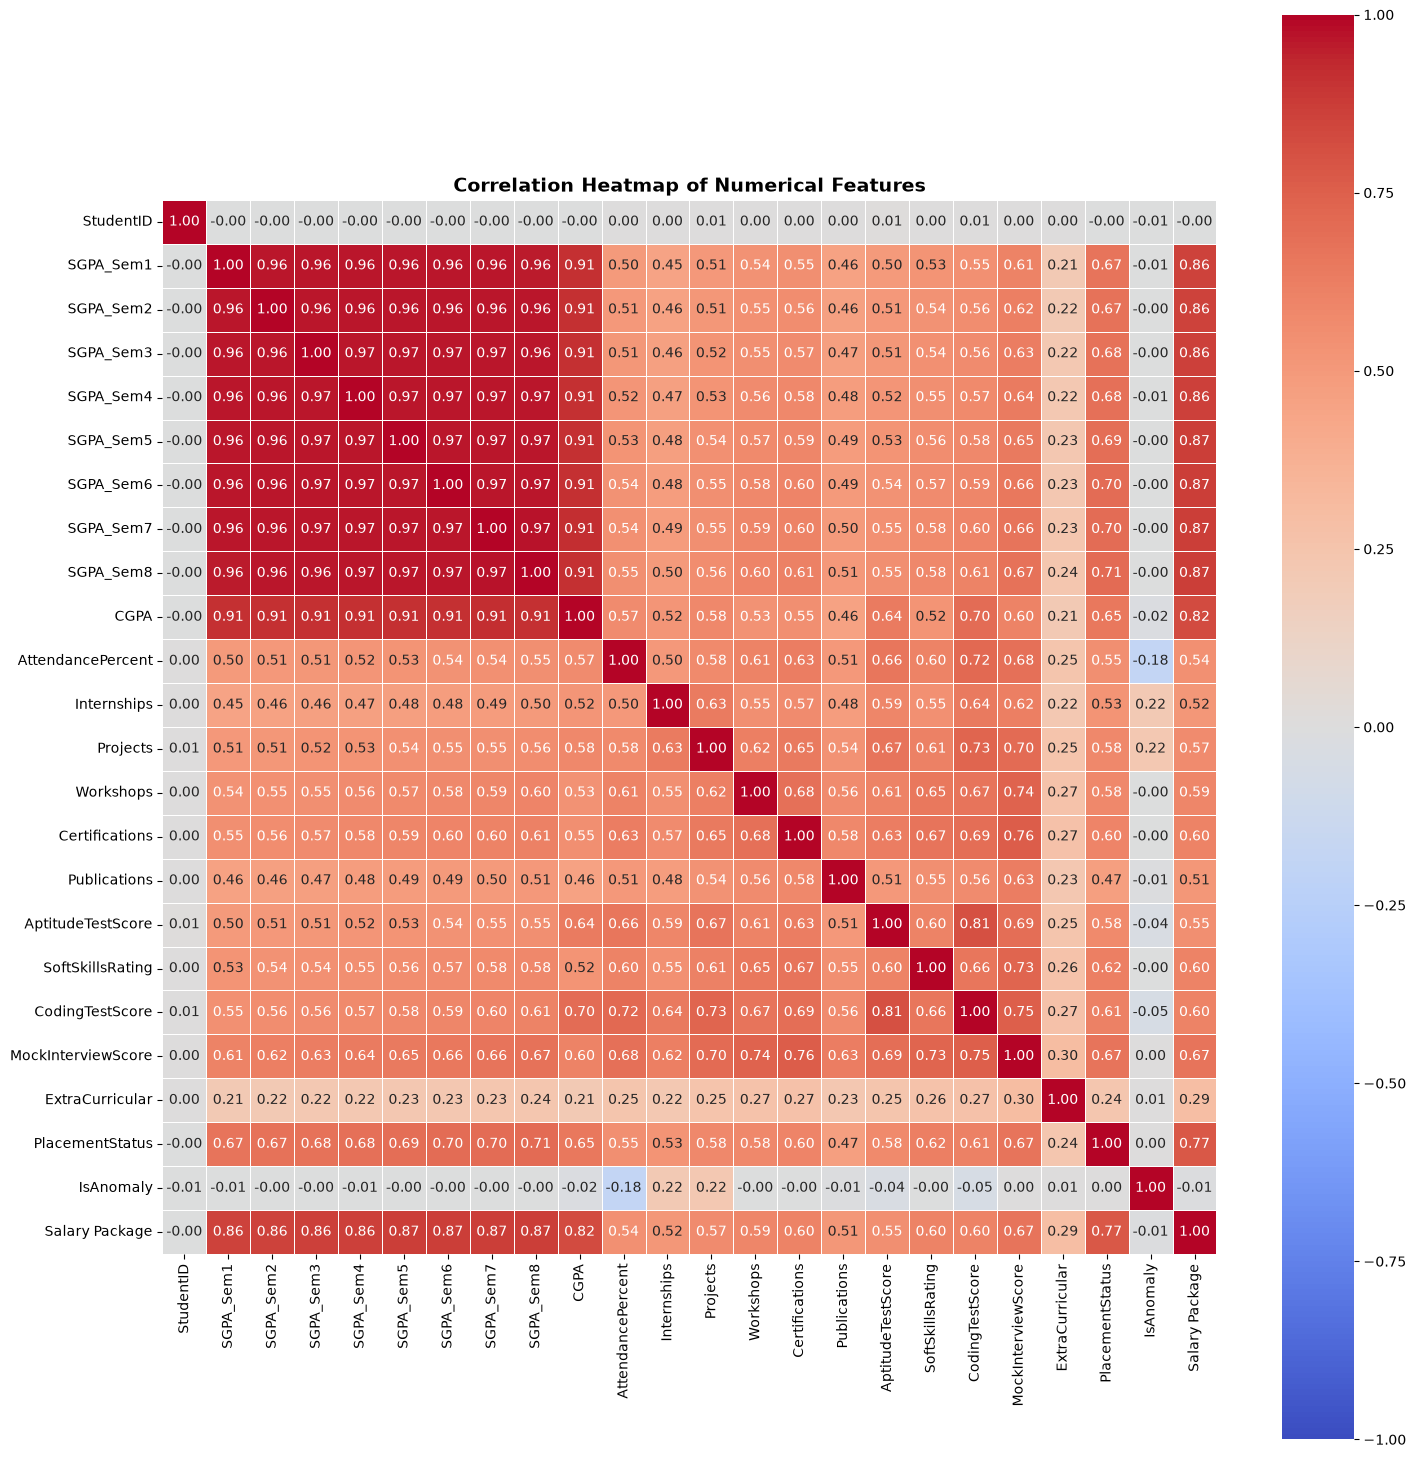

In [ ]:
# Create Heatmap
import matplotlib.pyplot as plt
plt.figure(figsize=(15,15))
sns.heatmap(
corr_matrix,
annot=True,
cmap="coolwarm",
fmt=".2f",
vmin=-1,
vmax=1,
square=True,
linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()

In [16]:
# Create Heatmap
import matplotlib.pyplot as plt
plt.figure(figsize=(15,15))
sns.heatmap(
corr_matrix,
annot=True,
cmap="coolwarm",
fmt=".2f",
vmin=-1,
vmax=1,
square=True,
linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()

# Export Heatmap
import os
output_dir = "C:\\KLH\\Subjects\\Y25-ML\\practical\\Placement-Prediction-System\\outputs"
heatmap_path = os.path.join(output_dir, "correlation_heatmap.png")
plt.savefig(heatmap_path, dpi=300)
plt.close()
print(f"Exported heatmap to: {heatmap_path}")

Exported heatmap to: C:\KLH\Subjects\Y25-ML\practical\Placement-Prediction-System\outputs\correlation_heatmap.png


In [17]:

print(os.getcwd())

c:\KLH\Subjects\Y25-ML\practical\Placement-Prediction-System\notebooks


In [18]:
# -------------------------------------------------------------
# 3. Produce Boxplots: Numerical Features vs PlacementStatus
# -------------------------------------------------------------
target_col = "PlacementStatus"
if target_col in df.columns:
    for col in numerical_cols:
        plt.figure(figsize=(6, 5))
        sns.boxplot(
            x=target_col,
            y=col,
            data=df,
            palette="Set2",
            hue=target_col,
            legend=False
        )
        plt.title(f"{col} vs {target_col}", fontsize=12, fontweight="bold")
        plt.xlabel(target_col)
        plt.ylabel(col)
        plt.tight_layout()
        

        # Save the boxplot
        boxplot_filename = f"boxplot_{col}_vs_{target_col}.png"

        # Create complete file path
        boxplot_path = os.path.join(output_dir, boxplot_filename)

        # Save the figure
        plt.savefig(boxplot_path,    dpi=300,    bbox_inches="tight")

        # Close the figure
        plt.close()

        # Display confirmation message
        print(f"Exported boxplot to: {boxplot_path}")

    else:
        print(f"\nTarget column '{target_col}' not found in dataset. Skipping boxplots.")

        print("\nAll EDA tasks completed successfully!")



Exported boxplot to: C:\KLH\Subjects\Y25-ML\practical\Placement-Prediction-System\outputs\boxplot_StudentID_vs_PlacementStatus.png
Exported boxplot to: C:\KLH\Subjects\Y25-ML\practical\Placement-Prediction-System\outputs\boxplot_SGPA_Sem1_vs_PlacementStatus.png
Exported boxplot to: C:\KLH\Subjects\Y25-ML\practical\Placement-Prediction-System\outputs\boxplot_SGPA_Sem2_vs_PlacementStatus.png
Exported boxplot to: C:\KLH\Subjects\Y25-ML\practical\Placement-Prediction-System\outputs\boxplot_SGPA_Sem3_vs_PlacementStatus.png
Exported boxplot to: C:\KLH\Subjects\Y25-ML\practical\Placement-Prediction-System\outputs\boxplot_SGPA_Sem4_vs_PlacementStatus.png
Exported boxplot to: C:\KLH\Subjects\Y25-ML\practical\Placement-Prediction-System\outputs\boxplot_SGPA_Sem5_vs_PlacementStatus.png
Exported boxplot to: C:\KLH\Subjects\Y25-ML\practical\Placement-Prediction-System\outputs\boxplot_SGPA_Sem6_vs_PlacementStatus.png
Exported boxplot to: C:\KLH\Subjects\Y25-ML\practical\Placement-Prediction-System\o

In [19]:
#boxplots
numerical_columns = [
    "Age",
    "CGPA",
    "Internships",
    "Projects",
    "Coding_Skills",
    "Communication_Skills",
    "Aptitude_Test_Score",
    "Soft_Skills_Rating",
    "Certifications",
    "Backlogs"
]


fig6= plt.figure(figsize=(14,8))

df[numerical_columns].boxplot()

plt.xticks(rotation=45)

plt.show()

KeyError: "['Age', 'Coding_Skills', 'Communication_Skills', 'Aptitude_Test_Score', 'Soft_Skills_Rating', 'Backlogs'] not in index"

<Figure size 1400x800 with 0 Axes>

In [ ]:
fig7= sns.boxplot(x='Placement_Status', y='Certifications', data=df)

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages("EDA_Report.pdf") as pdf:

    pdf.savefig(fig1)
    pdf.savefig(fig2)
    pdf.savefig(fig3)
    pdf.savefig(fig5)
    pdf.savefig(fig6)
    

print("EDA Report saved successfully.")

In [ ]:
#==========================================================
# Export Complete EDA Report
#==========================================================

with PdfPages("EDA_Report.pdf") as pdf:

    #------------------------------------------------------
    # Page 1 : Missing Value Heatmap
    #------------------------------------------------------

    plt.figure(figsize=(12,6))

    sns.heatmap(df.isnull(),
                cbar=True,
                yticklabels=False,
                cmap="viridis")

    plt.title("Missing Value Heatmap")
    plt.xlabel("Features")
    plt.ylabel("Samples")

    pdf.savefig()
    plt.close()


    #------------------------------------------------------
    # Page 2 : Histograms (6 Features)
    #------------------------------------------------------

    numerical_features = [
        "CGPA",
        "Age",
        "Coding_Skills",
        "Communication_Skills",
        "Aptitude_Test_Score",
        "Backlogs"
    ]

    fig, axes = plt.subplots(3,2,figsize=(14,12))

    axes = axes.flatten()

    for i,col in enumerate(numerical_features):

        axes[i].hist(df[col],
                     bins=15,
                     edgecolor='black')

        axes[i].set_title(col)

    plt.tight_layout()

    pdf.savefig()
    plt.close()


    #------------------------------------------------------
    # Page 3 : Placement by Branch
    #------------------------------------------------------

    plt.figure(figsize=(10,6))

    sns.countplot(
        data=df,
        x="Branch",
        hue="Placement_Status"
    )

    plt.title("Placement Status by Branch")

    plt.xticks(rotation=45)

    pdf.savefig()
    plt.close()


    #------------------------------------------------------
    # Page 4 : Correlation Heatmap
    #------------------------------------------------------

    plt.figure(figsize=(10,8))

    corr = df.select_dtypes(include=np.number).corr()

    sns.heatmap(
        corr,
        annot=True,
        cmap="coolwarm",
        fmt=".2f"
    )

    plt.title("Correlation Heatmap")

    pdf.savefig()

    plt.close()


    #------------------------------------------------------
    # Page 5 : Boxplots
    #------------------------------------------------------

    fig, axes = plt.subplots(3,2,figsize=(14,12))

    axes = axes.flatten()

    for i,col in enumerate(numerical_features):

        sns.boxplot(
            y=df[col],
            ax=axes[i]
        )

        axes[i].set_title(col)

    plt.tight_layout()

    pdf.savefig()

    plt.close()

print("EDA_Report.pdf created successfully.")